# Project 1 — ElasticNet
## Rental Price Prediction (correlated + irrelevant features)

Predicting monthly rental price from a mix of correlated features (sqft, num_rooms, num_bathrooms — all correlated with each other) plus some irrelevant noise features (wall_color_score, num_windows).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
np.random.seed(42)
pd.set_option('display.max_columns', None)


## 1. Generate / Load Data

In [2]:
n = 700
sqft = np.random.normal(900, 300, n).clip(300, 3000)
num_rooms = (sqft/350 + np.random.normal(0,0.5,n)).clip(1,None).round()
num_bathrooms = (num_rooms/2 + np.random.normal(0,0.3,n)).clip(1,None).round()
distance_to_city = np.random.uniform(0, 25, n)

wall_color_score = np.random.uniform(0, 10, n)     # irrelevant
num_windows = np.random.poisson(6, n)               # irrelevant

rent = (300 + 1.8*sqft + 150*num_rooms + 100*num_bathrooms - 25*distance_to_city
        + np.random.normal(0, 150, n))

df = pd.DataFrame({'sqft': sqft, 'num_rooms': num_rooms, 'num_bathrooms': num_bathrooms,
                    'distance_to_city': distance_to_city, 'wall_color_score': wall_color_score,
                    'num_windows': num_windows, 'rent': rent})
df.head()


,sqft,num_rooms,num_bathrooms,distance_to_city,wall_color_score,num_windows,rent
0,1049.014246,3.0,1.0,3.415023,3.245118,9,2802.143638
1,858.520710,3.0,2.0,16.290994,2.695119,6,2001.329402
2,1094.306561,3.0,2.0,18.464936,1.909266,3,2625.119246
3,1356.908957,3.0,2.0,7.890684,6.946410,7,3336.042870
4,829.753988,2.0,1.0,16.120815,2.187156,2,1629.840551


## 2. Preprocessing

In [3]:
X = df.drop('rent', axis=1)
y = df['rent']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 3. Train Model

In [4]:
from sklearn.linear_model import ElasticNet, ElasticNetCV

en_cv = ElasticNetCV(alphas=[0.1, 1, 10, 50], l1_ratio=[0.1, 0.5, 0.7, 0.9, 1.0], cv=5, max_iter=10000)
en_cv.fit(X_train_scaled, y_train)
print("Best alpha:", en_cv.alpha_, "Best l1_ratio:", en_cv.l1_ratio_)

model = ElasticNet(alpha=en_cv.alpha_, l1_ratio=en_cv.l1_ratio_, max_iter=10000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)


Best alpha: 0.1 Best l1_ratio: 1.0


## 4. Evaluate

In [5]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 137.96413082566824
RMSE: 167.72192221070253
R2 Score: 0.9566966508751521


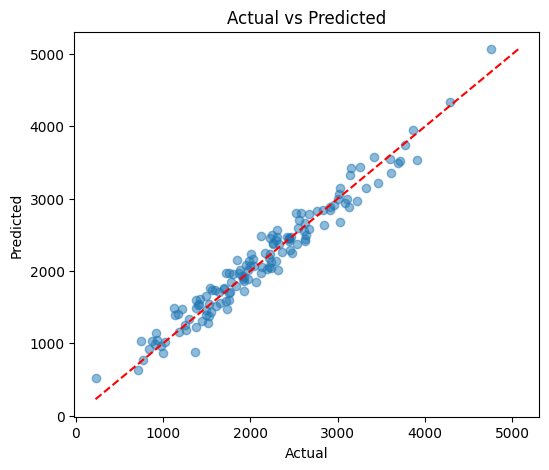

In [6]:
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual'); plt.ylabel('Predicted'); plt.title('Actual vs Predicted')
plt.show()


## Takeaways
- Compare coefficients against pure Lasso and pure Ridge fits on the same data — ElasticNet should shrink the irrelevant features (wall_color_score, num_windows) while keeping the correlated group (sqft, num_rooms, num_bathrooms) more evenly weighted than Lasso would.
- Next steps: try `l1_ratio=1.0` (pure Lasso) vs the CV-chosen ratio and compare how the correlated features get treated differently.

---
# Project 2 — Your Turn
**Dataset:** Exercise dataset (`seaborn.load_dataset('exercise')`) — predict `pulse` from diet, kind of exercise, and time (has both categorical and numeric features).

```python
import seaborn as sns
exercise = sns.load_dataset('exercise')
```
**Tasks:** encode categorical columns, scale numeric ones, use `ElasticNetCV` to find best alpha/l1_ratio, train, evaluate with MAE/RMSE/R².
